<a href="https://colab.research.google.com/github/larevelyn/sp-urban-analytics/blob/main/notebooks/ANALISE_CRIMINALIDADE_SP_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Sincronizar pasta abaixo no seu drive: 
# https://drive.google.com/drive/folders/1-vwQv5PzO8vKrOakO0HuZTFYEP1o7_bZ?usp=sharing

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install unidecode python-calamine -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 22.3 MB/s eta 0:00:0000:01


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import monotonically_increasing_id, split, trim, col, Column, coalesce, isnull, translate, round
from pyspark.sql.functions import avg, col, rand, when, lower, regexp_extract, regexp_replace, expr, create_map, lit
import pyspark.sql.functions as F
import pandas as pd
import geopandas as gpd
import unicodedata
from unidecode import unidecode
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import glob
from numpy import quantile
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import requests, io

In [5]:
spark = SparkSession.builder \
    .appName("Analise Criminalidade SP") \
    .getOrCreate()

In [ ]:
# Base criada a partir da base abaixo e com alguns tratamentos feitos no notebook TRATA_BASE_CRIMES
# https://www.ssp.sp.gov.br/assets/estatistica/transparencia/spDados/SPDadosCriminais_2025.xlsx
df_crimes = spark.read.parquet("drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/dados_criminais/dados_criminais.parquet")

Aqui iremos criar um "depara" de bairro por latitude e longitude, visto que não existe um padrão entre os nomes de bairros na base de dados criminais e outras bases

In [16]:
df_coords_distintas_pd = (df_crimes.select("LATITUDE", "LONGITUDE").dropDuplicates().toPandas())

In [ ]:
gdf_distritos = gpd.read_file("https://raw.githubusercontent.com/codigourbano/distritos-sp/master/distritos-sp.geojson")

gdf_coords = gpd.GeoDataFrame((df_coords_distintas_pd),
                                            geometry=gpd.points_from_xy(df_coords_distintas_pd["LONGITUDE"], 
                                                                        df_coords_distintas_pd["LATITUDE"]), crs="EPSG:4326")

gdf_coords_com_distrito = (gpd.sjoin(gdf_mapa_coords, gdf_distritos[["ds_nome", "ds_subpref", "geometry"]], how="left", predicate="within")
                              .query("ds_nome.notna() and ds_subpref.notna()")
                              .drop_duplicates())

In [18]:
df_coords_bairro = spark.createDataFrame(gdf_coords_com_distrito[["ds_nome", "ds_subpref", "LATITUDE", "LONGITUDE"]])

In [43]:
# A perda aqui é minima (menos de 1%) logo, não vale a pena tentar classificar, fora que, 
# boa parte dos casos, se tratam de registros na grande São Paulo, por isso eu troquei left por inner

# left
# +-------------------+-----------------+
# |            % nulos|      % não nulos|
# +-------------------+-----------------+
# |0.06312566742242119|99.93687433257757|
# +-------------------+-----------------+

# inner 
# +-------+-----------+
# |% nulos|% não nulos|
# +-------+-----------+
# |    0.0|      100.0|
# +-------+-----------+

df_crimes_agg_bairro = (df_crimes.join(F.broadcast(df_coords_bairro), on=["LATITUDE", "LONGITUDE"], how="inner")
                                 .groupBy('Categoria_Crime', 'NATUREZA_APURADA', 'ds_nome', 'ds_subpref')
                                 .agg(F.countDistinct("NUM_BO").alias("QTD_CRIMES"))
                                 .orderBy("Categoria_Crime")
                                 .withColumnRenamed("ds_nome", "Bairro_norm"))

In [45]:
# https://repositorio.seade.gov.br/dataset/populacao-residente-municipio-de-sao-paulo
df_pop = (spark.read
          .option("header", "true")       
          .option("inferSchema", "true")  
          .option("encoding", "iso-8859-1")
          .option("delimiter", ";")        
          .csv("/content/drive/MyDrive/Colab Notebooks/Analise_Urbana_SP/BASES/populacao/estimativa_pop_indicadores_msp.csv"))

In [46]:
acentos = "áàãâäéèêëíìîïóòõôöúùûüçÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇ"
sem_acentos = "aaaaaeeeeiiiiooooouuuucAAAAAEEEEIIIIOOOOOUUUUC"

df_pop = (df_pop.filter(col("ano") == 2024)
                .groupBy("distritos")
                .agg(F.sum("populacao").alias("populacao"))
                .withColumn("Bairro_norm", F.upper(F.translate(col("distritos"), acentos, sem_acentos))))

In [49]:
df_pop_crimes = (df_crimes_agg_bairro
                    .join(df_pop.select("Bairro_norm", "populacao"), on="Bairro_norm", how="left")
                    .groupBy("ds_subpref", "Bairro_norm", "populacao")
                    .agg(F.sum("QTD_CRIMES").alias("QTD_CRIMES"))
                    .withColumn("taxa_crimes", col("QTD_CRIMES") / col("populacao")))



In [54]:
df_pop_crimes_pd = df_pop_crimes.toPandas()

scaler = MinMaxScaler()
df_pop_crimes_pd[["crimes_norm"]] = scaler.fit_transform(df_pop_crimes_pd[["taxa_crimes"]])

In [55]:
df_pop_crimes_pd.sort_values(by='crimes_norm', ascending=False).head(10)

,ds_subpref,Bairro_norm,populacao,QTD_CRIMES,taxa_crimes,crimes_norm
66,SE,SE,23209,8488,0.365720,1.000000
46,MOOCA,BRAS,39822,8519,0.213927,0.568996
30,SE,REPUBLICA,61058,10402,0.170363,0.445298
8,MOOCA,PARI,17321,2915,0.168293,0.439421
52,LAPA,BARRA FUNDA,36499,5749,0.157511,0.408808
42,PINHEIROS,PINHEIROS,66007,10208,0.154650,0.400684
67,SE,BOM RETIRO,33179,4843,0.145966,0.376026
11,SE,CONSOLACAO,53270,7646,0.143533,0.369118
95,SE,BELA VISTA,58525,7032,0.120154,0.302735
1,SANTO AMARO,SANTO AMARO,88344,8825,0.099894,0.245207


In [56]:
# base de dados com geolocalização dos distritos de sp
url = "https://raw.githubusercontent.com/codigourbano/distritos-sp/master/distritos-sp.geojson"
gdf = gpd.read_file(url)

In [57]:
df_mapa = df_pop_crimes_pd.merge(gdf, left_on=["Bairro_norm"], right_on=["ds_nome"], how="left")

gdf_mapa = gpd.GeoDataFrame(df_mapa, geometry="geometry", crs="EPSG:4326")

gdf_mapa["centroid"] = gdf_mapa.geometry.centroid
gdf_mapa["centroid_x"] = gdf_mapa.centroid.x
gdf_mapa["centroid_y"] = gdf_mapa.centroid.y

/tmp/ipykernel_6990/716757746.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mapa["centroid"] = gdf_mapa.geometry.centroid
/tmp/ipykernel_6990/716757746.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mapa["centroid_x"] = gdf_mapa.centroid.x
/tmp/ipykernel_6990/716757746.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mapa["centroid_y"] = gdf_mapa.centroid.y


/tmp/ipykernel_6990/2652284435.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Reds")


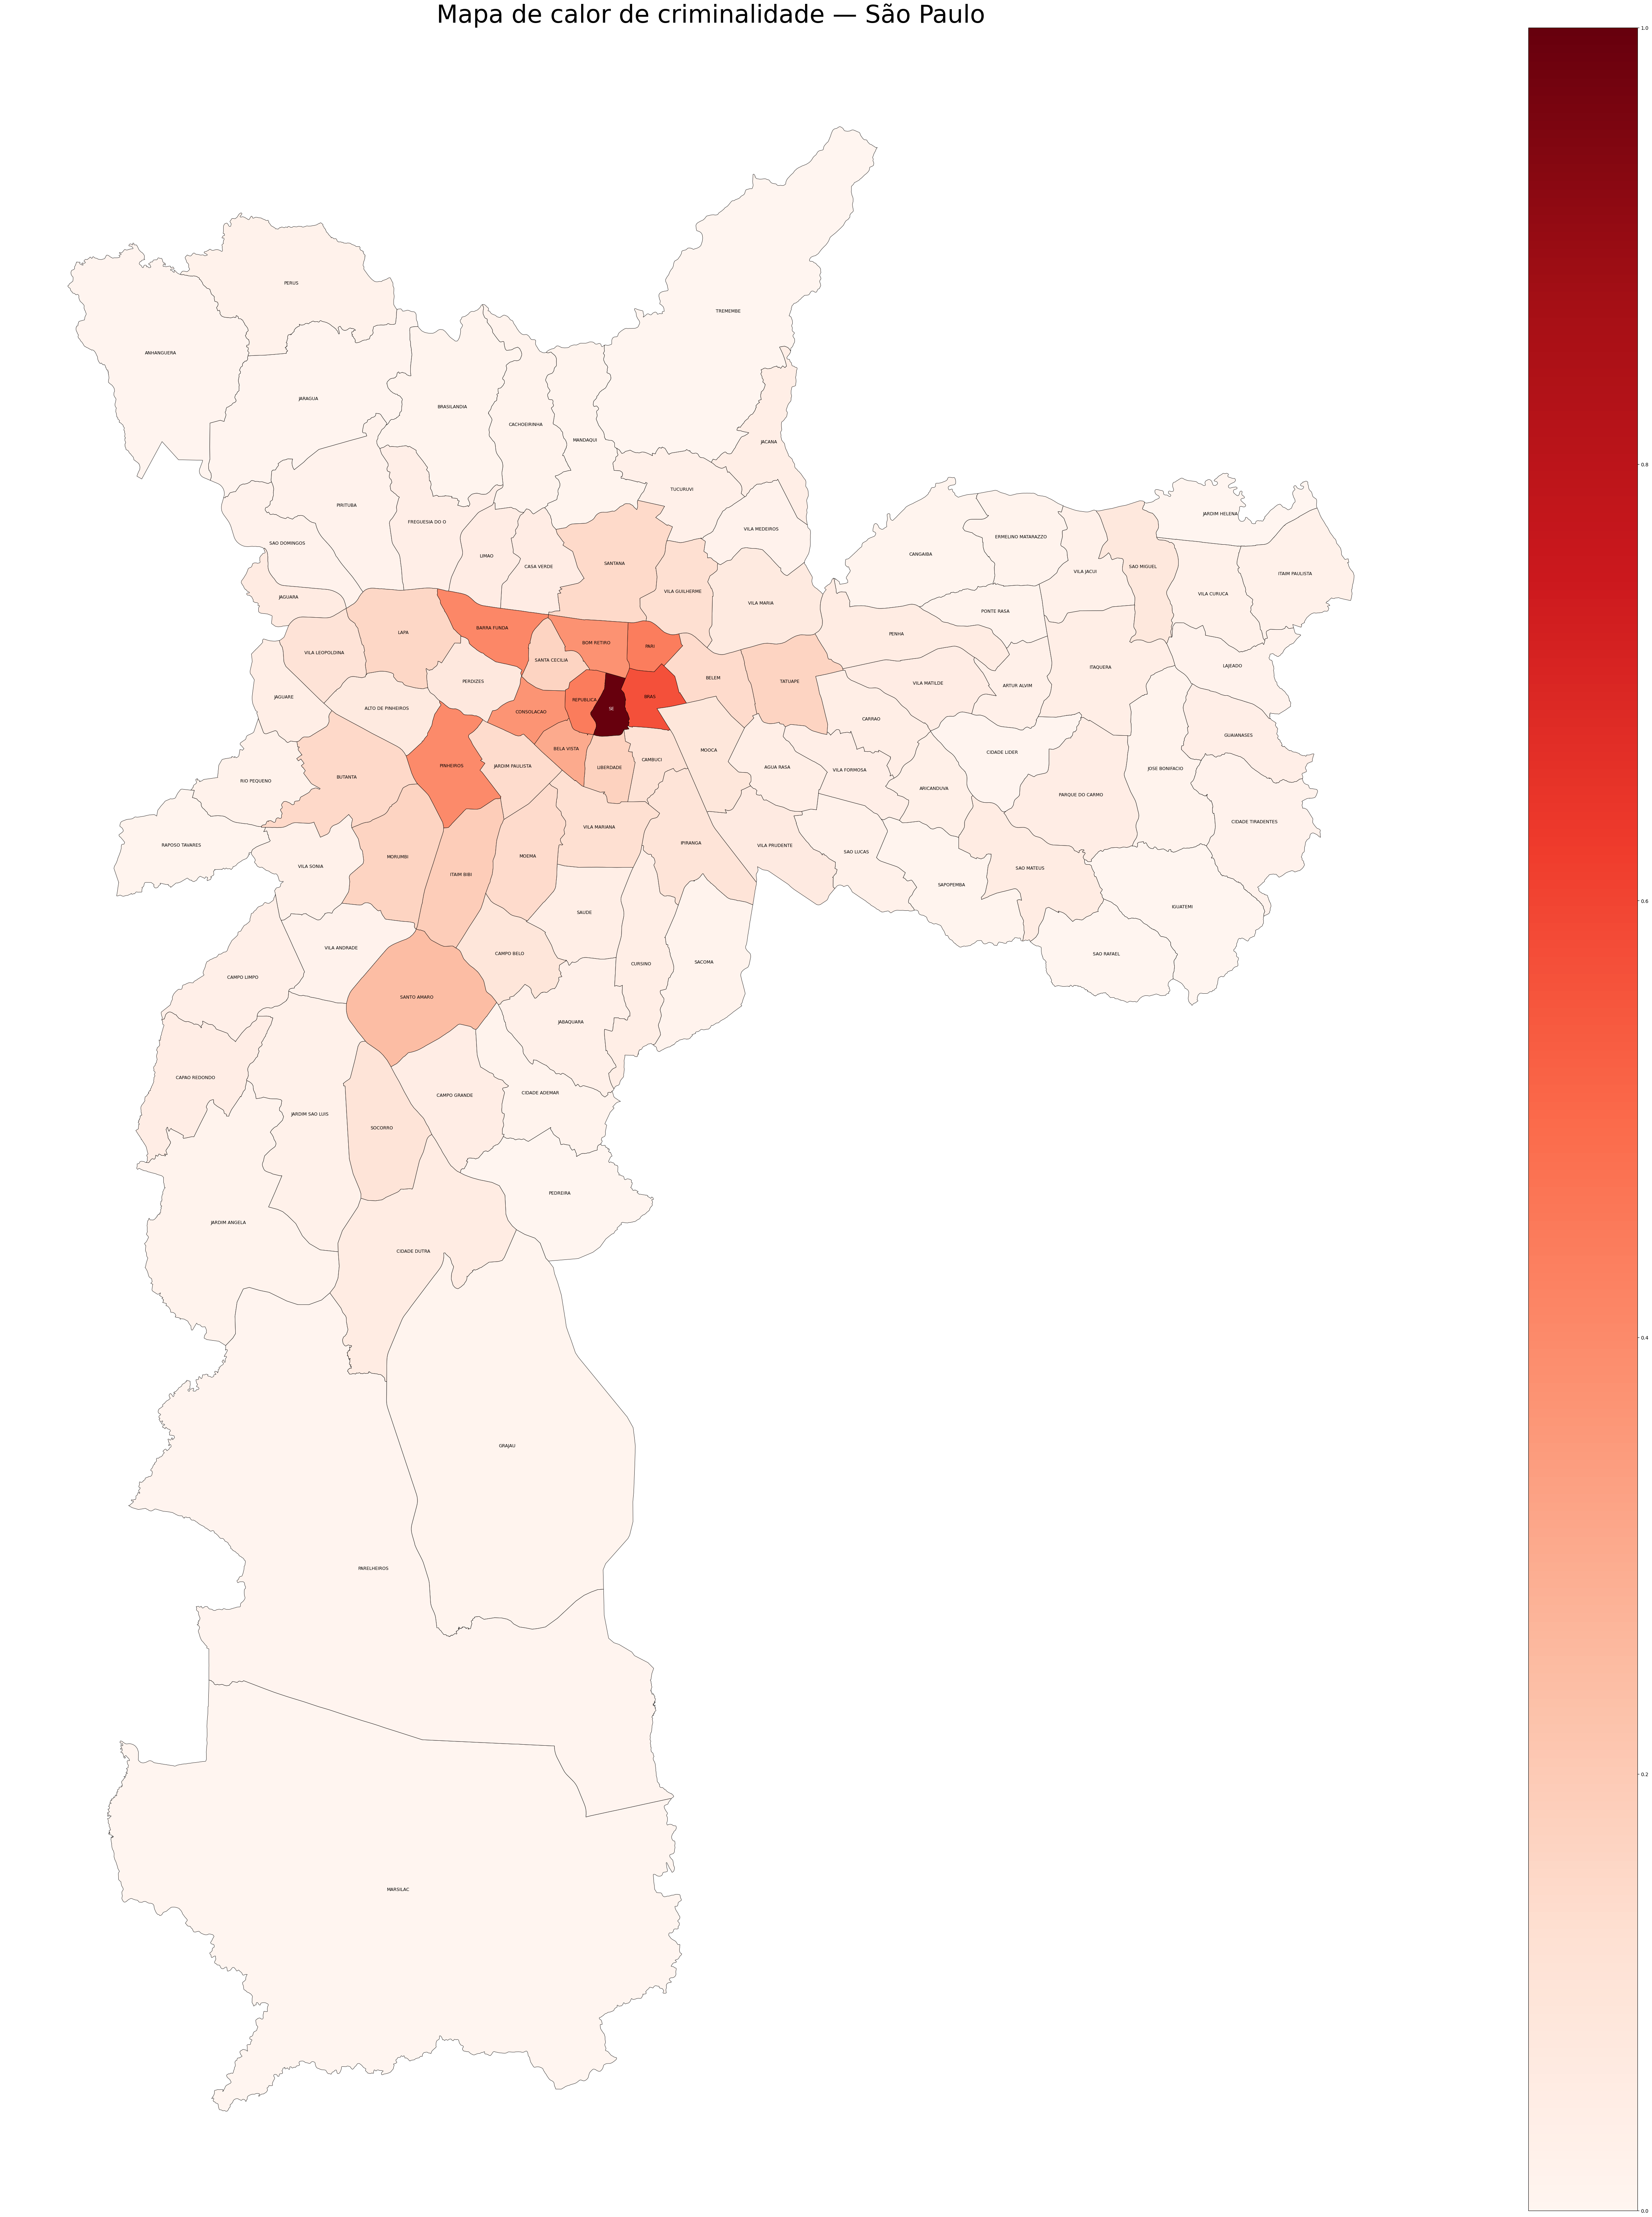

In [62]:
fig, ax = plt.subplots(figsize=(80, 80))
gdf_mapa.plot(column="crimes_norm", cmap="Reds", legend=True,
            linewidth=0.6, edgecolor="black", ax=ax)

# Normaliza os valores para mapear no colormap
norm = mcolors.Normalize(vmin=gdf_mapa["crimes_norm"].min(),
                        vmax=gdf_mapa["crimes_norm"].max())
cmap = cm.get_cmap("Reds")

for x, y, label, valor in zip(gdf_mapa["centroid_x"],
                            gdf_mapa["centroid_y"],
                            gdf_mapa["Bairro_norm"],
                            gdf_mapa["crimes_norm"]):
    # Pega a cor RGBA do fundo daquele polígono
    r, g, b, _ = cmap(norm(valor))

    # Calcula luminância perceptual
    luminancia = 0.299 * r + 0.587 * g + 0.114 * b

    # Escuro → texto branco | Claro → texto preto
    cor_texto = "white" if luminancia < 0.3 else "black"

    ax.text(x, y, label, fontsize=9, ha="center", va="center",
            color=cor_texto)

ax.set_title(f"Mapa de calor de criminalidade — São Paulo", fontsize=50)
ax.set_axis_off()
plt.show()
